## Setup

In [1]:
# Libraries
import pyvisa                    # Communication (also install pyvisa-py or NI VISA)
import matplotlib.pyplot as plt  # Plots
import numpy as np               # Maths
import pandas as pd              # DataFrames
import time                      # Delays
from tqdm.notebook import tqdm   # Progress bars (use 'for i in tqdm(iter)')
import os                        # Used for determining platform

In [2]:
from Devices.ARIS import ARIS
from Devices.Luminator import Luminator
from Devices.CUBE import CUBE

In [3]:
from Utilities.SetupLogging import setupLogging
logger = setupLogging()

In [19]:
from Devices.PM100 import PM100
rm = pyvisa.ResourceManager()
tap = PM100(rm, 'USB0::0x1313::0x8078::P0017770::INSTR', "ppms-tap", "Config/PM100/PPMS-tap.json")

In [22]:
tap.setWavelength(580)
tap.getPower()

np.float64(1.5702368131129848e-05)

In [6]:
p = np.polynomial.Polynomial([16.41109734800112, 2.855948945215623, -0.9960620983730097, 1.1637547289081147, -1.211827966197374])
p

Polynomial([16.41109735,  2.85594895, -0.9960621 ,  1.16375473, -1.21182797], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [7]:
p(1e-7)

np.float64(16.411097633596004)

In [8]:
df = pd.read_csv("./Config/PPMS_tap_calibration.csv")

In [9]:
df

,Unnamed: 0,wavelength,tap,head
0,0,310.0,2.767509e-08,6.597589e-07
1,1,311.0,2.940753e-08,6.556946e-07
2,2,312.0,2.741193e-08,6.226254e-07
3,3,313.0,2.912243e-08,6.130187e-07
4,4,314.0,2.901278e-08,5.943595e-07
...,...,...,...,...
646,646,956.0,3.462349e-07,5.311394e-06
647,647,957.0,3.074183e-07,4.710016e-06
648,648,958.0,2.732081e-07,4.221231e-06
649,649,959.0,2.392331e-07,3.773607e-06


Polynomial([16.41109735,  2.85594895, -0.9960621 ,  1.16375473, -1.21182797], domain=[400., 800.], window=[-1.,  1.], symbol='x')

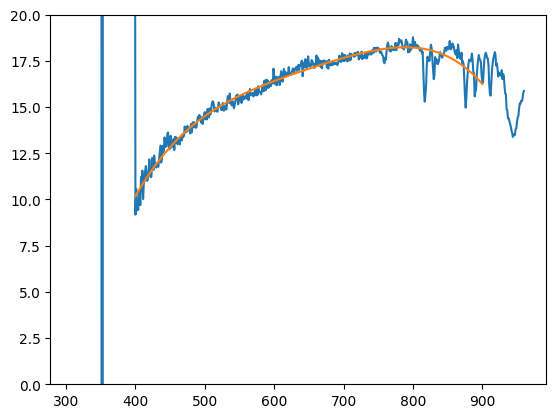

In [10]:
mask = np.logical_and(df.wavelength >= 400, df.wavelength <= 800 )
plt.plot(df.wavelength, df['head'] / df.tap)
plt.ylim(0, 20)
pf = np.polynomial.Polynomial.fit(df.wavelength[mask], df['head'][mask] / df.tap[mask], 4)
xs = np.linspace(400, 900, 100)
ys = pf(xs)
plt.plot(xs, ys)
pf

In [11]:
pf.convert().coef

array([-1.30700751e+02,  8.55655598e-01, -1.92271412e-03,  1.96321129e-06,
       -7.57392479e-10])

In [18]:
import json
with open("Config/PM100/PPMS-tap.json", "r") as file:
    d = json.load(file)

d

{'ppms-tap': {'c0': -130.700751,
  'c1': 0.855655598,
  'c2': -0.00192271412,
  'c3': 1.96321129e-06,
  'c4': -7.57392479e-10,
  'cal_lower': 400,
  'cal_upper': 800,
  'description': 'PPMS measurement head to tap ratio'}}